# Linear Classification from Scratch – Credit Card Default Prediction  
**Logistic Regression Implementation – Machine Learning Lab**

**Objective**  
Implement **binary logistic regression** from scratch using gradient descent and sigmoid activation, and apply it to a practical fintech problem: **predicting whether a credit card holder will default on their next payment**.

**Dataset**  
- **Default of Credit Card Clients** (UCI Machine Learning Repository – Taiwan, 2005)  
- ~30,000 customers with 23 features: credit limit, demographics (age, sex, education, marriage), repayment status (6 months), bill amounts, and previous payments  
- Target: default.payment.next.month (1 = default, 0 = no default) – imbalanced (~22% default rate)  
- Direct link: https://raw.githubusercontent.com/amirshnll/default-of-credit-card-clients-classification/master/dataset.csv  
- Real banking use case: credit risk scoring and early default detection

**What this notebook demonstrates**  
- Loading and scaling real financial tabular data  
- From-scratch logistic regression (sigmoid + weighted binary cross-entropy loss)  
- Gradient descent optimization with loss tracking  
- Handling class imbalance using balanced class weights  
- Full comparison with scikit-learn’s LogisticRegression  
- Comprehensive evaluation: Accuracy, Precision, Recall, F1-score, ROC-AUC + ROC curve  
- Feature importance via coefficient visualization  
- Training loss curve to show convergence

**Key Learning Outcomes**  
- Understand logistic regression as a linear probabilistic classifier  
- See how gradient descent minimizes cross-entropy loss  
- Appreciate the role of class weighting in imbalanced classification  
- Interpret model coefficients (e.g., late payments strongly increase default risk)  
- Recognize why ROC-AUC is more reliable than accuracy in imbalanced settings  
- Limitations: linear assumption; advanced models (trees, XGBoost) usually perform better


Run all cells to train and evaluate a from-scratch logistic regression model on real credit default data!

In [52]:
%matplotlib inline

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression as SklearnLR
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

In [56]:
# ── 1. Load real Credit Card Default dataset (stable mirror) ─────
print("Loading Credit Card Default dataset...")
url = "https://raw.githubusercontent.com/amirshnll/default-of-credit-card-clients-classification/master/dataset.csv"
df = pd.read_csv(url)

print(f"Dataset shape: {df.shape}")
print("Columns:", df.columns.tolist())
print("Default rate:", df['Y'].mean().round(4), "(imbalanced)")
print(df.head(3))

if 'Y' not in df.columns:
    raise ValueError("Target column 'Y' not found!")

Loading Credit Card Default dataset...
Dataset shape: (30000, 25)
Columns: ['ID', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', 'Y']
Default rate: 0.2212 (imbalanced)
   ID      X1  X2  X3  X4  X5  X6  X7  X8  X9  ...    X15    X16    X17   X18  \
0   1   20000   2   2   1  24   2   2  -1  -1  ...      0      0      0     0   
1   2  120000   2   2   2  26  -1   2   0   0  ...   3272   3455   3261     0   
2   3   90000   2   2   2  34   0   0   0   0  ...  14331  14948  15549  1518   

    X19   X20   X21   X22   X23  Y  
0   689     0     0     0     0  1  
1  1000  1000  1000     0  2000  1  
2  1500  1000  1000  1000  5000  0  

[3 rows x 25 columns]


In [58]:
# ── 2. Features & Target ────────────────────────────────────────
X = df.drop('Y', axis=1)
y = df['Y']

In [59]:
# ── 3. Train/Test split + Scaling ───────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print("Train default rate:", y_train.mean().round(4))

Train: 22500 | Test: 7500
Train default rate: 0.2212


In [60]:
# ── 4. From-scratch Logistic Regression (Gradient Descent) ──────
class LogisticRegressionScratch:
    def __init__(self, lr=0.01, epochs=2000, class_weight=None):
        self.lr = lr
        self.epochs = epochs
        self.class_weight = class_weight
        self.weights = None
        self.bias = None
        self.loss_history = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        # Class weights for imbalance
        if self.class_weight == 'balanced':
            n0 = np.sum(y == 0)
            n1 = np.sum(y == 1)
            w0 = n_samples / (2.0 * n0) if n0 > 0 else 1.0
            w1 = n_samples / (2.0 * n1) if n1 > 0 else 1.0
        else:
            w0 = w1 = 1.0

        for epoch in range(self.epochs):
            linear = np.dot(X, self.weights) + self.bias
            preds = self.sigmoid(linear)

            # Weighted gradient
            error = preds - y
            dw = (1/n_samples) * np.dot(X.T, error * np.where(y == 1, w1, w0))
            db = (1/n_samples) * np.sum(error * np.where(y == 1, w1, w0))

            self.weights -= self.lr * dw
            self.bias   -= self.lr * db

            # Log loss
            loss = -np.mean(
                y * np.log(preds + 1e-10) + (1 - y) * np.log(1 - preds + 1e-10)
            )
            self.loss_history.append(loss)

            if epoch % 400 == 0:
                print(f"Epoch {epoch:4d} | Loss: {loss:.4f}")

    def predict_proba(self, X):
        return self.sigmoid(np.dot(X, self.weights) + self.bias)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

In [61]:
# ── 5. Train scratch model ──────────────────────────────────────
print("\nTraining from-scratch Logistic Regression...")
model_scratch = LogisticRegressionScratch(lr=0.01, epochs=2000, class_weight='balanced')
model_scratch.fit(X_train_scaled, y_train)

y_pred_scratch = model_scratch.predict(X_test_scaled)
y_prob_scratch = model_scratch.predict_proba(X_test_scaled)


Training from-scratch Logistic Regression...
Epoch    0 | Loss: 0.6931
Epoch  400 | Loss: 0.6315
Epoch  800 | Loss: 0.6169
Epoch 1200 | Loss: 0.6099
Epoch 1600 | Loss: 0.6064


In [62]:
# ── 6. scikit-learn comparison ──────────────────────────────────
model_sk = SklearnLR(class_weight='balanced', max_iter=2000)
model_sk.fit(X_train_scaled, y_train)

y_pred_sk = model_sk.predict(X_test_scaled)
y_prob_sk = model_sk.predict_proba(X_test_scaled)[:, 1]

In [63]:
# ── 7. Evaluation function ──────────────────────────────────────
def print_metrics(y_true, y_pred, y_prob, label):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_prob)
    print(f"\n{label}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1-score : {f1:.4f}")
    print(f"  ROC-AUC  : {auc:.4f}")

print_metrics(y_test, y_pred_scratch, y_prob_scratch, "Scratch Logistic Regression")
print_metrics(y_test, y_pred_sk, y_prob_sk, "scikit-learn LogisticRegression")


Scratch Logistic Regression
  Accuracy : 0.6776
  Precision: 0.3672
  Recall   : 0.6323
  F1-score : 0.4646
  ROC-AUC  : 0.7151

scikit-learn LogisticRegression
  Accuracy : 0.6809
  Precision: 0.3704
  Recall   : 0.6323
  F1-score : 0.4672
  ROC-AUC  : 0.7165


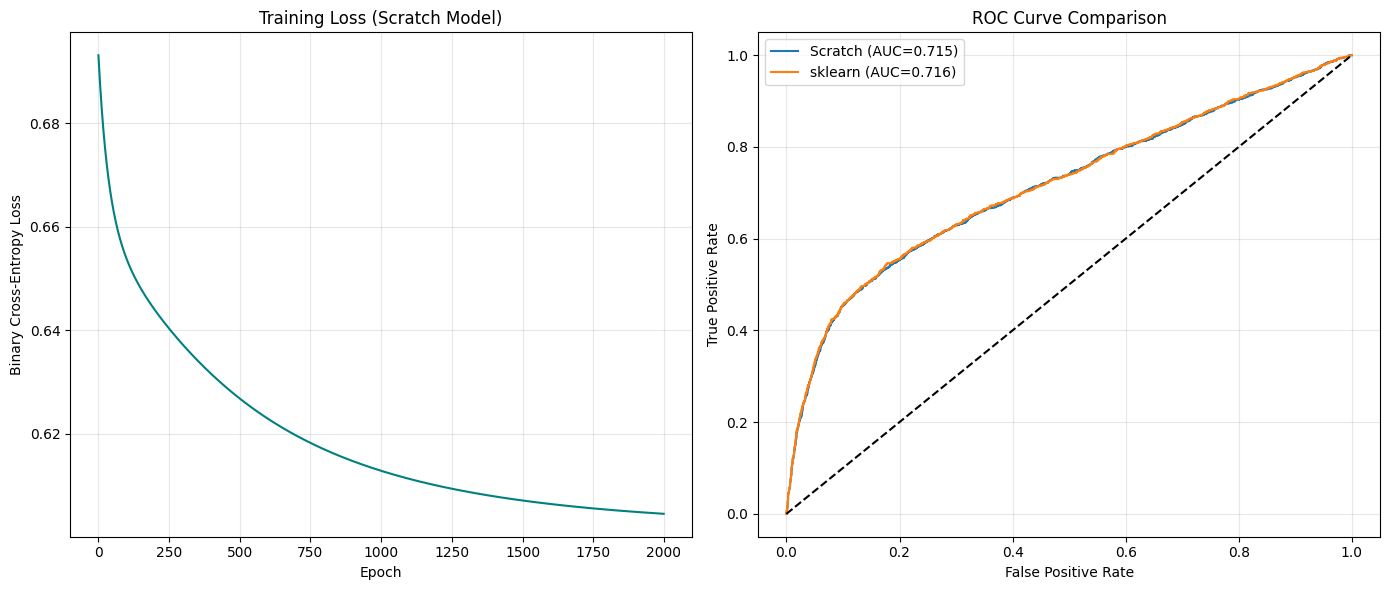

In [66]:
# ── 8. Plots ────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Loss curve (scratch only)
ax1.plot(model_scratch.loss_history, color='teal')
ax1.set_title("Training Loss (Scratch Model)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Binary Cross-Entropy Loss")
ax1.grid(True, alpha=0.3)
# ROC Curve comparison
fpr_s, tpr_s, _ = roc_curve(y_test, y_prob_scratch)
fpr_sk, tpr_sk, _ = roc_curve(y_test, y_prob_sk)

ax2.plot(fpr_s, tpr_s, label=f"Scratch (AUC={roc_auc_score(y_test, y_prob_scratch):.3f})")
ax2.plot(fpr_sk, tpr_sk, label=f"sklearn (AUC={roc_auc_score(y_test, y_prob_sk):.3f})")
ax2.plot([0,1], [0,1], 'k--')
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("ROC Curve Comparison")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



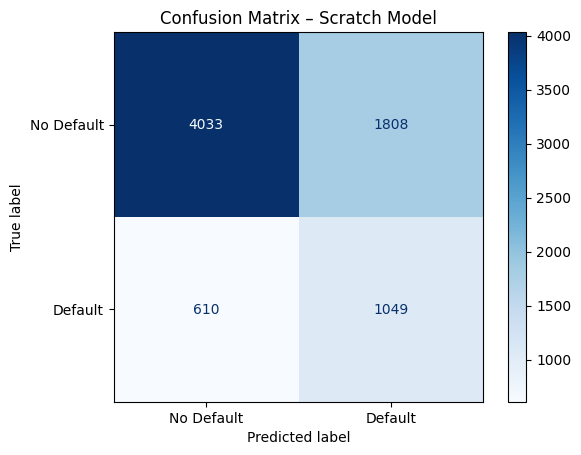

In [68]:
# Confusion Matrix (scratch model)
cm = confusion_matrix(y_test, y_pred_scratch)
disp = ConfusionMatrixDisplay(cm, display_labels=["No Default", "Default"])
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix – Scratch Model")
plt.show()

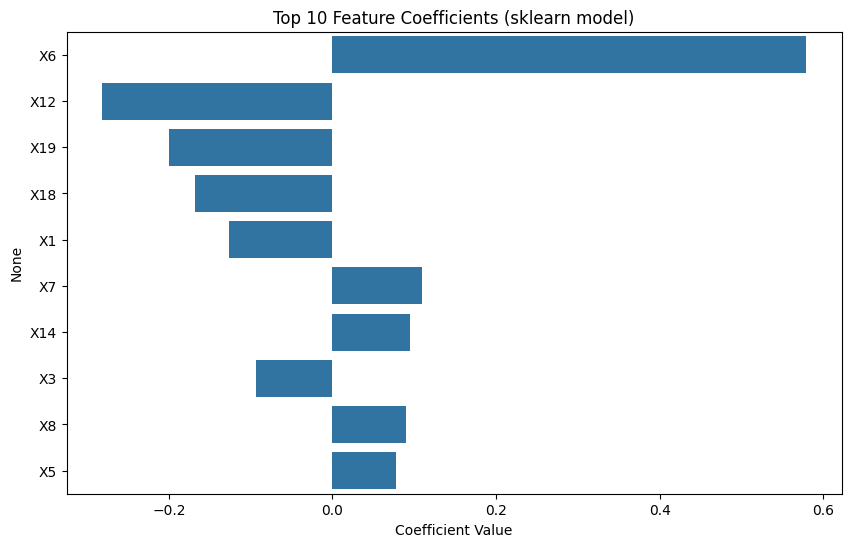

In [69]:
# Feature importance (coefficients from sklearn)
coefs = model_sk.coef_[0]
sorted_idx = np.argsort(np.abs(coefs))[::-1][:10]
top_features = X.columns[sorted_idx]
top_coefs = coefs[sorted_idx]

plt.figure(figsize=(10, 6))
sns.barplot(x=top_coefs, y=top_features)
plt.title("Top 10 Feature Coefficients (sklearn model)")
plt.xlabel("Coefficient Value")
plt.show()
